# PopQA V2 — Latent-RAG: Token Embeddings & KNN

Extends `PopQA_Benchmark.ipynb` with three key changes:

1. **Entity-level splits**: zero `obj` overlap between train and test — no seen-entity leakage.
2. **Two concept-vector types**:
   - *Residual-L16*: 4 QA prompts → L16 hidden state (same as V1, re-evaluated on fair splits).
   - *Token-Embed*: mean of Llama token embedding table lookups — smoother, generalises better.
3. **KNN-smoothed inference** (Token-Embed only): at test time, retrieve the K nearest training entity adapter outputs by cosine similarity and interpolate — helps unseen entities.

**Variants evaluated** (train / val / test for each):
| Variant | Concept vector | Inference |
|---|---|---|
| `residual_direct` | L16 residual, 4 QA prompts | adapter forward |
| `embed_direct` | mean token embedding | adapter forward |
| `embed_knn` | mean token embedding | KNN-smoothed adapter outputs |
| `perfect_rag` | gold answer in context | — (no adapter) |


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix: prevent duplicate OpenMP crash on Windows

# ── Imports & Setup ───────────────────────────────────────────────────────────
import ast, random, copy, time, json, re, pathlib
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import google.generativeai as genai

from tqdm.auto import tqdm
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from typing_extensions import TypedDict
!pip install datasets -q
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.model_selection import train_test_split

# ── Credentials ───────────────────────────────────────────────────────────────
HF_TOKEN       = os.getenv("HF_TOKEN")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("HF_TOKEN       : set")
else:
    print("WARNING: HF_TOKEN not set")

if GEMINI_API_KEY:
    print("GEMINI_API_KEY : set")
else:
    print("WARNING: GEMINI_API_KEY not set")

# ── GPU check ─────────────────────────────────────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU detected. Check your RunAI GPU allocation.")

print(f"\nGPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"CUDA   : {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")

C:\Users\carme\AppData\Local\Temp\ipykernel_9480\674079705.py:12: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


HF_TOKEN       : set
GEMINI_API_KEY : set


RuntimeError: No CUDA GPU detected. Check your RunAI GPU allocation.

## Cell 2: Configuration

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
_RESULTS_DIR = str(pathlib.Path.cwd() / "PopQA_V2")


@dataclass
class ExperimentConfig:
    # --- Model ---
    model_name:  str         = "meta-llama/Llama-3.1-8B-Instruct"
    device_map:  str         = "auto"
    torch_dtype: torch.dtype = torch.bfloat16

    # --- Paths ---
    base_dir: str = _RESULTS_DIR

    # --- Dataset ---
    popqa_s_pop_threshold: int   = 500   # keep subjects with s_pop < this
    train_ratio:           float = 0.80
    seed:                  int   = 42

    # --- Extraction (residual method) ---
    extraction_layer:  int  = 16
    extraction_pos:    str  = "resid_post"
    normalize_vectors: bool = True

    # --- Injection ---
    injection_layer: int = 16

    # --- Architecture ---
    architecture_id:    int = 4
    adapter_hidden_dim: int = 4096

    # --- Training ---
    use_lowercase: bool = True

    # --- Phase 1: Weighted CE + BERTTune ---
    phase1_epochs:        int   = 20
    phase1_lr:            float = 5e-4
    phase1_batch_size:    int   = 16
    phase1_dropout:       float = 0.15
    entity_token_weight:  float = 8.0
    berttune_lambda:      float = 3.0
    berttune_temperature: float = 1.0

    # --- Phase 2: GRPO ---
    grpo_epochs:          int   = 5
    grpo_lr:              float = 1e-5
    grpo_batch_size:      int   = 4
    grpo_num_generations: int   = 4
    grpo_max_new_tokens:  int   = 64
    grpo_temperature:     float = 0.7
    grpo_kl_coeff:        float = 0.05
    grpo_max_examples:    int   = 600
    grpo_reward_weights: Dict[str, float] = field(default_factory=lambda: {
        "contains_entity":   0.5,
        "matches_reference": 0.5,
    })
    judge_model_name: str = "Qwen/Qwen2.5-3B-Instruct"

    # --- KNN (token-embed inference) ---
    knn_k:           int   = 5
    knn_temperature: float = 0.1

    # --- Multi-prompt extraction (residual method, identical to V1) ---
    extraction_prompts: List[str] = field(default_factory=lambda: [
        "Q: What is {word}? A:",
        "Q: Describe {word}. A:",
        "Q: Tell me about {word}. A:",
        "Q: What do you know about {word}? A:",
    ])

    words: List[str] = field(default_factory=list)

    def get_safe_model_name(self):
        return self.model_name.replace("/", "_")

    @property
    def cache_dir(self):
        p = os.path.join(self.base_dir, "learning_cache")
        os.makedirs(p, exist_ok=True)
        return p

    # ── Adapter save paths (one pair per variant) ──────────────────────────────
    @property
    def adapter_residual_p1(self):
        p = os.path.join(self.base_dir, "trained_adapters"); os.makedirs(p, exist_ok=True)
        return os.path.join(p, f"adapter_{self.get_safe_model_name()}_L{self.injection_layer}_residual_phase1.pt")

    @property
    def adapter_residual_grpo(self):
        p = os.path.join(self.base_dir, "trained_adapters"); os.makedirs(p, exist_ok=True)
        return os.path.join(p, f"adapter_{self.get_safe_model_name()}_L{self.injection_layer}_residual_grpo.pt")

    @property
    def adapter_embed_p1(self):
        p = os.path.join(self.base_dir, "trained_adapters"); os.makedirs(p, exist_ok=True)
        return os.path.join(p, f"adapter_{self.get_safe_model_name()}_L{self.injection_layer}_embed_phase1.pt")

    @property
    def adapter_embed_grpo(self):
        p = os.path.join(self.base_dir, "trained_adapters"); os.makedirs(p, exist_ok=True)
        return os.path.join(p, f"adapter_{self.get_safe_model_name()}_L{self.injection_layer}_embed_grpo.pt")

    # ── Split CSVs ─────────────────────────────────────────────────────────────
    @property
    def train_csv(self):
        return os.path.join(self.base_dir, "dataset", "train.csv")

    @property
    def val_csv(self):
        return os.path.join(self.base_dir, "dataset", "val.csv")

    @property
    def test_csv(self):
        return os.path.join(self.base_dir, "dataset", "test.csv")

    @property
    def entity_split_csv(self):
        return os.path.join(self.base_dir, "dataset", "entity_split.csv")


cfg = ExperimentConfig()
for d in [cfg.base_dir,
          os.path.join(cfg.base_dir, "dataset"),
          os.path.join(cfg.base_dir, "results"),
          os.path.join(cfg.base_dir, "plots")]:
    os.makedirs(d, exist_ok=True)

print(f"Results directory : {cfg.base_dir}")
print(f"s_pop threshold   : {cfg.popqa_s_pop_threshold}")
print(f"Split             : 80 / 10 / 10  (ENTITY-LEVEL — zero obj overlap)")
print(f"KNN K             : {cfg.knn_k},  temperature: {cfg.knn_temperature}")


Results directory : PopQA_V2
s_pop threshold   : 500
Split             : 80 / 10 / 10  (ENTITY-LEVEL — zero obj overlap)
KNN K             : 5,  temperature: 0.1


## Cell 3: Load & Filter PopQA

Fresh download from HuggingFace (`akariasai/PopQA`). Nothing is read from the old `PopQA/` folder.


In [3]:
# ── Load & Filter PopQA ───────────────────────────────────────────────────────
DATASET_DIR    = os.path.join(cfg.base_dir, "dataset")
CANDIDATES_CSV = os.path.join(DATASET_DIR, "filtered_candidates.csv")

if os.path.exists(CANDIDATES_CSV):
    print(f"Loading cached candidates: {CANDIDATES_CSV}")
    df_candidates = pd.read_csv(CANDIDATES_CSV)
    df_candidates["answers_list"] = df_candidates["answers_list"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
else:
    print("Loading PopQA from HuggingFace (akariasai/PopQA)...")
    raw_ds = load_dataset("akariasai/PopQA", split="test")
    df_raw = raw_ds.to_pandas()
    print(f"Full PopQA: {len(df_raw):,} rows | columns: {list(df_raw.columns)}")

    df_pop = df_raw[df_raw["s_pop"] < cfg.popqa_s_pop_threshold].copy()
    print(f"After s_pop < {cfg.popqa_s_pop_threshold}: {len(df_pop):,} examples")

    def _parse_answers(val):
        if isinstance(val, list):
            return val
        try:
            return json.loads(val)
        except Exception:
            try:
                return ast.literal_eval(val)
            except Exception:
                return [str(val)]

    df_pop["answers_list"] = df_pop["possible_answers"].apply(_parse_answers)
    df_candidates = df_pop[["subj", "prop", "obj", "question", "answers_list",
                             "s_pop", "o_pop"]].copy().reset_index(drop=True)
    df_candidates.to_csv(CANDIDATES_CSV, index=False)
    print(f"Saved {len(df_candidates):,} candidates -> {CANDIDATES_CSV}")

print(f"\nCandidates: {len(df_candidates):,}")
print(f"Unique prop types:\n{df_candidates['prop'].value_counts().to_string()}")
df_candidates.head(3)


Loading cached candidates: PopQA_V2\dataset\filtered_candidates.csv

Candidates: 5,451
Unique prop types:
prop
author            845
director          715
genre             617
country           576
screenwriter      486
place of birth    447
sport             404
producer          336
occupation        313
composer          261
father            179
religion          121
capital            98
capital of         32
mother             21


,subj,prop,obj,question,answers_list,s_pop,o_pop
0,George Rankin,occupation,politician,What is George Rankin's occupation?,"[politician, political leader, political figur...",142,25692
1,John Mayne,occupation,journalist,What is John Mayne's occupation?,"[journalist, journo, journalists]",236,24952
2,Henry Feilden,occupation,politician,What is Henry Feilden's occupation?,"[politician, political leader, political figur...",58,25692


## Cell 4: Load Model & Tokenizer

Loads Llama-3.1-8B-Instruct once (frozen). Used for no-context filtering,
residual concept vector extraction, and all generation / training steps.


In [ ]:
# ── Load Model & Tokenizer ────────────────────────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.padding_side = "right"
tokenizer.pad_token    = tokenizer.eos_token

print("Loading model (bfloat16, device_map=auto)...")
model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    device_map=cfg.device_map,
    torch_dtype=cfg.torch_dtype,
)
model.eval()
for p in model.parameters():
    p.requires_grad = False

print(f"Model loaded.  Hidden size : {model.config.hidden_size}")
print(f"               Num layers  : {model.config.num_hidden_layers}")
print(f"               Device      : {model.device}")
print(f"VRAM used (model): {torch.cuda.memory_allocated() / 1e9:.2f} GB")


## Cell 5: No-Context Filtering

Run the base model (no adapter, no context) on every candidate.
Keep only examples where the output does **not** contain any accepted answer —
these are genuinely unknown to the base model. Results cached.


In [4]:
# ── No-Context Filtering ──────────────────────────────────────────────────────
# Identical logic to PopQA_Benchmark.ipynb
NO_CTX_CSV = os.path.join(DATASET_DIR, "no_context_check.csv")


def _model_knows(generated: str, answers_list: list) -> bool:
    gen_lower = generated.lower()
    return any(str(ans).lower() in gen_lower for ans in answers_list)


@torch.inference_mode()
def _generate_no_ctx(question: str, max_new_tokens: int = 64) -> str:
    msgs      = [{"role": "user", "content": question}]
    prompt    = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs    = tokenizer(prompt, return_tensors="pt").to(model.device)
    out_ids   = model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)


if os.path.exists(NO_CTX_CSV):
    print(f"Loading cached no-context results: {NO_CTX_CSV}")
    df_no_ctx = pd.read_csv(NO_CTX_CSV)
    df_no_ctx["answers_list"] = df_no_ctx["answers_list"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
else:
    print(f"Running no-context evaluation on {len(df_candidates):,} candidates...")
    records = []
    for _, row in tqdm(df_candidates.iterrows(), total=len(df_candidates), desc="No-context"):
        generated = _generate_no_ctx(row["question"])
        records.append({
            "subj":        row["subj"],
            "prop":        row["prop"],
            "obj":         row["obj"],
            "question":    row["question"],
            "answers_list": row["answers_list"],
            "s_pop":       row["s_pop"],
            "generated":   generated,
            "model_knew":  _model_knows(generated, row["answers_list"]),
        })
    df_no_ctx = pd.DataFrame(records)
    df_no_ctx.to_csv(NO_CTX_CSV, index=False)
    print(f"Saved: {NO_CTX_CSV}")

total, knew = len(df_no_ctx), df_no_ctx["model_knew"].sum()
print(f"\nTotal      : {total:,}")
print(f"Knew       : {knew:,}  ({100*knew/total:.1f}%)")
print(f"Did NOT know: {total-knew:,}  ({100*(total-knew)/total:.1f}%) — dataset")


Loading cached no-context results: PopQA_V2\dataset\no_context_check.csv

Total      : 5,451
Knew       : 547  (10.0%)
Did NOT know: 4,904  (90.0%) — dataset


## Cell 6: Entity-Level Split  *(New — zero obj overlap)*

**Key change vs V1**: split by unique `obj` entity (not by row).
This guarantees that no answer entity seen during training appears in val or test.


In [5]:
# ── Entity-Level Split ────────────────────────────────────────────────────────
ENTITY_SPLIT_CSV = cfg.entity_split_csv
TRAIN_CSV        = cfg.train_csv
VAL_CSV          = cfg.val_csv
TEST_CSV         = cfg.test_csv
KEEP_COLS        = ["subj", "prop", "obj", "question", "answers_list"]

if (os.path.exists(TRAIN_CSV) and os.path.exists(VAL_CSV)
        and os.path.exists(TEST_CSV) and os.path.exists(ENTITY_SPLIT_CSV)):
    print("Entity-level splits already exist — skipping.")
else:
    df_unknown = df_no_ctx[~df_no_ctx["model_knew"]].copy().reset_index(drop=True)
    print(f"Unknown examples: {len(df_unknown):,}")

    # ── Map each unique entity to its dominant prop category (for stratification)
    entity_prop = (
        df_unknown.groupby("obj")["prop"]
        .agg(lambda s: s.value_counts().index[0])
        .reset_index()
        .rename(columns={"prop": "dominant_prop"})
    )
    unique_ents  = entity_prop["obj"].values
    strat_labels = entity_prop["dominant_prop"].values

    # ── 80 / 10+10  entity split (stratified by dominant prop)
    train_ents, valtest_ents, _, valtest_strat = train_test_split(
        unique_ents, strat_labels,
        test_size=0.20, random_state=cfg.seed, stratify=strat_labels,
    )
    val_ents, test_ents = train_test_split(
        valtest_ents, test_size=0.50, random_state=cfg.seed, stratify=valtest_strat,
    )

    # ── Sanity: zero overlap
    assert set(train_ents).isdisjoint(set(val_ents)),  "train/val entity overlap!"
    assert set(train_ents).isdisjoint(set(test_ents)), "train/test entity overlap!"
    assert set(val_ents).isdisjoint(set(test_ents)),   "val/test entity overlap!"

    # ── Save entity -> split assignment
    entity_split_df = pd.concat([
        pd.DataFrame({"obj": train_ents, "split": "train"}),
        pd.DataFrame({"obj": val_ents,   "split": "val"}),
        pd.DataFrame({"obj": test_ents,  "split": "test"}),
    ], ignore_index=True)
    entity_split_df.to_csv(ENTITY_SPLIT_CSV, index=False)

    # ── Assign examples to splits
    entity_to_split = dict(zip(entity_split_df["obj"], entity_split_df["split"]))
    df_unknown["split"] = df_unknown["obj"].map(entity_to_split)

    df_train = df_unknown[df_unknown["split"] == "train"][KEEP_COLS].reset_index(drop=True)
    df_val   = df_unknown[df_unknown["split"] == "val"][KEEP_COLS].reset_index(drop=True)
    df_test  = df_unknown[df_unknown["split"] == "test"][KEEP_COLS].reset_index(drop=True)

    df_train.to_csv(TRAIN_CSV, index=False)
    df_val.to_csv(VAL_CSV,     index=False)
    df_test.to_csv(TEST_CSV,   index=False)

    print(f"Train : {len(df_train):,} examples  |  unique obj: {df_train['obj'].nunique():,}")
    print(f"Val   : {len(df_val):,} examples    |  unique obj: {df_val['obj'].nunique():,}")
    print(f"Test  : {len(df_test):,} examples   |  unique obj: {df_test['obj'].nunique():,}")

# ── Verify zero overlap
ent_split = pd.read_csv(ENTITY_SPLIT_CSV)
train_set = set(ent_split[ent_split["split"]=="train"]["obj"])
val_set   = set(ent_split[ent_split["split"]=="val"]["obj"])
test_set  = set(ent_split[ent_split["split"]=="test"]["obj"])
print(f"\nEntity overlap train∩val  : {len(train_set & val_set)}")
print(f"Entity overlap train∩test : {len(train_set & test_set)}")
print(f"Entity overlap val∩test   : {len(val_set & test_set)}")
print("\nProp distribution — train:")
print(pd.read_csv(TRAIN_CSV)["prop"].value_counts().to_string())


Entity-level splits already exist — skipping.

Entity overlap train∩val  : 0
Entity overlap train∩test : 0
Entity overlap val∩test   : 0

Prop distribution — train:
prop
author            649
director          565
genre             490
screenwriter      372
place of birth    339
sport             300
occupation        275
producer          267
country           235
composer          198
father            135
religion           92
capital            34
capital of         22
mother             16


## Cell 7: Concept Vector Extraction — Residual-L16

Identical logic to `PopQA_Benchmark.ipynb`: 4 QA prompts → L16 hidden state → mean → L2-normalise.
Extracted for train, val, and test unique entities.


In [6]:
# ── Residual-L16 Concept Vector Extraction ────────────────────────────────────
# *** Identical to PopQA_Benchmark.ipynb ***

@torch.inference_mode()
def get_layer_activation(model, tokenizer, prompt: str,
                         layer_idx: int, which: str = "resid_post") -> torch.Tensor:
    enc  = tokenizer(prompt, return_tensors="pt", truncation=True, add_special_tokens=True)
    enc  = {k: v.to(model.device) for k, v in enc.items()}
    out  = model(**enc, output_hidden_states=True, use_cache=False)
    hs   = out.hidden_states
    acts = hs[layer_idx + 1] if which == "resid_post" else hs[layer_idx]
    length = enc["attention_mask"].sum(dim=1) - 1
    return acts[0, length[0]].detach().cpu()


def get_concept_vectors(cfg: ExperimentConfig, model, tokenizer,
                        words: List[str], split_tag: str = "train") -> dict:
    norm_tag = "norm" if cfg.normalize_vectors else "raw"
    filename = (f"{split_tag}_concepts_{cfg.get_safe_model_name()}"
                f"_L{cfg.extraction_layer}_{cfg.extraction_pos}_{norm_tag}_multiQA.pt")
    filepath = os.path.join(cfg.cache_dir, filename)

    if os.path.exists(filepath):
        print(f"Loading from cache: {filepath}")
        return torch.load(filepath, map_location="cpu", weights_only=False)["vectors"]

    print(f"Computing residual concept vectors for {len(set(words))} unique entities...")
    concept_vecs = {}
    for word in tqdm(set(words), desc="Residual concept vectors"):
        key  = word.lower() if cfg.use_lowercase else word
        vecs = []
        for tmpl in cfg.extraction_prompts:
            prompt = tmpl.replace("{word}", word)
            vec    = get_layer_activation(model, tokenizer, prompt,
                                          cfg.extraction_layer, cfg.extraction_pos)
            vecs.append(vec)
        avg_vec = torch.stack(vecs).mean(dim=0)
        if cfg.normalize_vectors:
            avg_vec = F.normalize(avg_vec, dim=-1)
        concept_vecs[key] = avg_vec

    torch.save({"words": list(concept_vecs.keys()), "vectors": concept_vecs}, filepath)
    print(f"Saved: {filepath}")
    return concept_vecs


# Extract for train + val + test (we need vecs for all splits for evaluation)
_all_words_from_csvs = []
for csv_path in [cfg.train_csv, cfg.val_csv, cfg.test_csv]:
    _df = pd.read_csv(csv_path)
    _all_words_from_csvs.extend(_df["obj"].tolist())
_train_words = list({r["obj"] for _, r in pd.read_csv(cfg.train_csv).iterrows()})
_val_words   = list({r["obj"] for _, r in pd.read_csv(cfg.val_csv).iterrows()})
_test_words  = list({r["obj"] for _, r in pd.read_csv(cfg.test_csv).iterrows()})

residual_vecs_train = get_concept_vectors(cfg, model, tokenizer, _train_words, "v2_train_residual")
residual_vecs_val   = get_concept_vectors(cfg, model, tokenizer, _val_words,   "v2_val_residual")
residual_vecs_test  = get_concept_vectors(cfg, model, tokenizer, _test_words,  "v2_test_residual")
residual_vecs_all   = {**residual_vecs_train, **residual_vecs_val, **residual_vecs_test}

print(f"Residual vecs — train: {len(residual_vecs_train)}, "
      f"val: {len(residual_vecs_val)}, test: {len(residual_vecs_test)}")
torch.cuda.empty_cache()


NameError: name 'model' is not defined

## Cell 8: Concept Vector Extraction — Token Embeddings  *(New)*

For each unique `obj`, tokenise the entity string, look up each token in
`model.model.embed_tokens` (the raw embedding table before any transformer computation),
and mean-pool across tokens. **No forward pass required** — just a lookup.

Similar entities have similar embeddings in this space, which should help the adapter
generalise to unseen entities at inference time.


In [ ]:
# ── Token Embedding Concept Vector Extraction ─────────────────────────────────

def get_token_embedding_vectors(cfg: ExperimentConfig, model, tokenizer,
                                words: List[str], split_tag: str = "train") -> dict:
    norm_tag = "norm" if cfg.normalize_vectors else "raw"
    filename = f"{split_tag}_concepts_{cfg.get_safe_model_name()}_token_embed_{norm_tag}.pt"
    filepath = os.path.join(cfg.cache_dir, filename)

    if os.path.exists(filepath):
        print(f"Loading from cache: {filepath}")
        return torch.load(filepath, map_location="cpu", weights_only=False)["vectors"]

    print(f"Computing token embedding vectors for {len(set(words))} unique entities...")
    # Detach the full embedding table to CPU once (avoids repeated GPU transfers)
    embed_table = model.model.embed_tokens.weight.detach().cpu().float()  # [V, D]

    concept_vecs = {}
    for word in tqdm(set(words), desc="Token embeddings"):
        key      = word.lower() if cfg.use_lowercase else word
        tok_ids  = tokenizer.encode(word, add_special_tokens=False)
        if not tok_ids:
            tok_ids = tokenizer.encode(word, add_special_tokens=True)
        vecs     = embed_table[tok_ids]           # [num_tokens, D]
        avg_vec  = vecs.mean(dim=0).to(cfg.torch_dtype)
        if cfg.normalize_vectors:
            avg_vec = F.normalize(avg_vec, dim=-1)
        concept_vecs[key] = avg_vec

    torch.save({"words": list(concept_vecs.keys()), "vectors": concept_vecs}, filepath)
    print(f"Saved: {filepath}")
    del embed_table
    return concept_vecs


embed_vecs_train = get_token_embedding_vectors(cfg, model, tokenizer, _train_words, "v2_train_embed")
embed_vecs_val   = get_token_embedding_vectors(cfg, model, tokenizer, _val_words,   "v2_val_embed")
embed_vecs_test  = get_token_embedding_vectors(cfg, model, tokenizer, _test_words,  "v2_test_embed")
embed_vecs_all   = {**embed_vecs_train, **embed_vecs_val, **embed_vecs_test}

print(f"Token embed vecs — train: {len(embed_vecs_train)}, "
      f"val: {len(embed_vecs_val)}, test: {len(embed_vecs_test)}")
torch.cuda.empty_cache()


## Cell 9: Embedding Space Sanity Check

For each test entity, compute cosine similarity to its nearest training neighbour
in both the residual and token-embedding spaces.
This tells us upfront whether the spaces are dense enough for KNN to be meaningful.


In [ ]:
# ── Embedding Space Analysis ──────────────────────────────────────────────────

def nearest_neighbor_sims(train_vecs: dict, test_vecs: dict) -> np.ndarray:
    keys_tr  = list(train_vecs.keys())
    mat_tr   = torch.stack([train_vecs[k] for k in keys_tr]).float()  # [N_tr, D]
    sims = []
    for key_te, vec_te in test_vecs.items():
        s = F.cosine_similarity(vec_te.float().unsqueeze(0), mat_tr).max().item()
        sims.append(s)
    return np.array(sims)


print("Computing nearest-neighbour similarities (test → train)...")
nn_sims_residual = nearest_neighbor_sims(residual_vecs_train, residual_vecs_test)
nn_sims_embed    = nearest_neighbor_sims(embed_vecs_train,    embed_vecs_test)

print(f"\nResidual-L16  NN cosine sim: "
      f"mean={nn_sims_residual.mean():.3f}, "
      f"median={np.median(nn_sims_residual):.3f}, "
      f"min={nn_sims_residual.min():.3f}, "
      f"max={nn_sims_residual.max():.3f}")
print(f"Token-Embed   NN cosine sim: "
      f"mean={nn_sims_embed.mean():.3f}, "
      f"median={np.median(nn_sims_embed):.3f}, "
      f"min={nn_sims_embed.min():.3f}, "
      f"max={nn_sims_embed.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sims, label in [
    (axes[0], nn_sims_residual, "Residual-L16"),
    (axes[1], nn_sims_embed,    "Token-Embed"),
]:
    ax.hist(sims, bins=40, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(sims.mean(), color="tomato", linestyle="--", label=f"mean={sims.mean():.3f}")
    ax.set_title(f"{label}: test→train NN cosine similarity")
    ax.set_xlabel("Cosine similarity"); ax.set_ylabel("Count")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
PLOTS_DIR = os.path.join(cfg.base_dir, "plots")
plt.savefig(os.path.join(PLOTS_DIR, "nn_similarity_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Higher mean sim for Token-Embed → KNN interpolation is more meaningful there.")


## Cell 10: Load Splits — Restart Checkpoint

Re-run Cells 1–2 (imports + config) and Cell 4 (model load), then run this cell
to restore all data splits and cached concept vectors from disk.


In [ ]:
# ── Load Train / Val / Test Splits ────────────────────────────────────────────

def _load_split(csv_path: str) -> List[dict]:
    df = pd.read_csv(csv_path)
    df["answers_list"] = df["answers_list"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    records = []
    for _, row in df.iterrows():
        obj  = str(row["obj"])
        prop = str(row["prop"])
        records.append({
            "entity_key":      obj.lower() if cfg.use_lowercase else obj,
            "entity_original": obj,
            "category_key":    prop.lower() if cfg.use_lowercase else prop,
            "question":        str(row["question"]),
            "answer":          str(row["answers_list"][0]) if row["answers_list"] else obj,
            "answers_list":    row["answers_list"],
        })
    return records


train_data = _load_split(cfg.train_csv)
val_data   = _load_split(cfg.val_csv)
test_data  = _load_split(cfg.test_csv)

cfg.words  = list({item["entity_original"] for item in train_data})

print(f"Train : {len(train_data):,} examples  | unique obj: {len(cfg.words):,}")
print(f"Val   : {len(val_data):,} examples")
print(f"Test  : {len(test_data):,} examples")

# ── Reload concept vectors from cache (if restarting after Cell 10) ─────────
# (These are already in memory if you ran Cells 7–9; this block is a no-op then)
_train_words = list({item["entity_original"] for item in train_data})
_val_words   = list({item["entity_original"] for item in val_data})
_test_words  = list({item["entity_original"] for item in test_data})

residual_vecs_train = get_concept_vectors(cfg, model, tokenizer, _train_words, "v2_train_residual")
residual_vecs_val   = get_concept_vectors(cfg, model, tokenizer, _val_words,   "v2_val_residual")
residual_vecs_test  = get_concept_vectors(cfg, model, tokenizer, _test_words,  "v2_test_residual")
residual_vecs_all   = {**residual_vecs_train, **residual_vecs_val, **residual_vecs_test}

embed_vecs_train = get_token_embedding_vectors(cfg, model, tokenizer, _train_words, "v2_train_embed")
embed_vecs_val   = get_token_embedding_vectors(cfg, model, tokenizer, _val_words,   "v2_val_embed")
embed_vecs_test  = get_token_embedding_vectors(cfg, model, tokenizer, _test_words,  "v2_test_embed")
embed_vecs_all   = {**embed_vecs_train, **embed_vecs_val, **embed_vecs_test}

print("All splits and concept vectors loaded.")


## Cell 11: Adapter Architecture (V4) — unchanged

2-layer MLP: `input_dim → hidden_dim → GELU → Dropout → input_dim`.


In [ ]:
# ── Adapter Architecture (V4) ─────────────────────────────────────────────────
# *** Identical to PopQA_Benchmark.ipynb ***

class InjectionAdapterV4(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 4096, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_adapter(cfg: ExperimentConfig, model) -> nn.Module:
    input_dim = model.config.hidden_size
    adapter   = InjectionAdapterV4(
        input_dim  = input_dim,
        hidden_dim = cfg.adapter_hidden_dim,
        dropout    = cfg.phase1_dropout,
    )
    n_params = sum(p.numel() for p in adapter.parameters())
    print(f"Adapter (arch {cfg.architecture_id}): {n_params:,} parameters")
    return adapter


## Cell 12: Training Helpers — BERTTune, hook, batch builder

Identical to `PopQA_Benchmark.ipynb`.


In [ ]:
# ── BERTTune Semantic Loss ─────────────────────────────────────────────────────
# *** Identical to PopQA_Benchmark.ipynb ***

def berttune_semantic_loss(
    logits:       torch.Tensor,
    target_ids:   torch.Tensor,
    embed_matrix: torch.Tensor,
    answer_mask:  torch.Tensor,
    temperature:  float = 1.0,
) -> torch.Tensor:
    B, T, V  = logits.shape
    probs     = F.softmax(logits.float() / temperature, dim=-1)
    soft_embs = probs @ embed_matrix.float()
    with torch.no_grad():
        ref_embs = embed_matrix.float()[target_ids.clamp(min=0)]
    mask      = answer_mask.float().unsqueeze(-1)
    soft_embs = soft_embs * mask
    ref_embs  = ref_embs  * mask
    denom     = mask.sum(dim=1).clamp(min=1e-8)
    soft_mean = soft_embs.sum(dim=1) / denom
    ref_mean  = ref_embs.sum(dim=1)  / denom
    cos_sim   = F.cosine_similarity(soft_mean, ref_mean, dim=-1)
    return 1.0 - cos_sim.mean()


def find_entity_token_spans(answer_ids: List[int], entity_ids: List[int]) -> List[int]:
    positions = []
    n, m = len(answer_ids), len(entity_ids)
    if m == 0:
        return positions
    for i in range(n - m + 1):
        if answer_ids[i : i + m] == entity_ids:
            positions.extend(range(i, i + m))
    return positions


def make_injection_hook(injection_vecs: torch.Tensor, injection_indices: List[int]):
    def hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        for b, idx in enumerate(injection_indices):
            if b < hs.shape[0] and idx < hs.shape[1]:
                hs[b, idx, :] = hs[b, idx, :] + injection_vecs[b]
        return (hs,) + output[1:] if isinstance(output, tuple) else hs
    return hook


def build_batch(items, tokenizer, cfg, concept_vecs):
    input_ids_list, labels_list, weights_list = [], [], []
    answer_masks_list, injection_indices, batch_vectors = [], [], []

    for item in items:
        vec = concept_vecs.get(item["entity_key"])
        if vec is None:
            continue

        msgs       = [{"role": "user", "content": item["question"]}]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        answer_str = item["answer"] + tokenizer.eos_token

        prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=False)
        ans_ids    = tokenizer.encode(answer_str, add_special_tokens=False)
        entity_ids = tokenizer.encode(item["entity_original"], add_special_tokens=False)
        entity_pos = set(find_entity_token_spans(ans_ids, entity_ids))
        weights    = [cfg.entity_token_weight if i in entity_pos else 1.0
                      for i in range(len(ans_ids))]

        full_ids = prompt_ids + ans_ids
        lbl_ids  = [-100] * len(prompt_ids) + ans_ids
        lbl_wts  = [0.0]  * len(prompt_ids) + weights
        ans_mask = [0.0]  * len(prompt_ids) + [1.0] * len(ans_ids)

        input_ids_list.append(torch.tensor(full_ids,    dtype=torch.long))
        labels_list.append(torch.tensor(lbl_ids,        dtype=torch.long))
        weights_list.append(torch.tensor(lbl_wts,       dtype=torch.float))
        answer_masks_list.append(torch.tensor(ans_mask, dtype=torch.float))
        injection_indices.append(len(prompt_ids) - 1)
        batch_vectors.append(vec)

    if not input_ids_list:
        return None

    pad        = tokenizer.pad_token_id
    input_ids  = torch.nn.utils.rnn.pad_sequence(input_ids_list,    batch_first=True, padding_value=pad)
    labels     = torch.nn.utils.rnn.pad_sequence(labels_list,       batch_first=True, padding_value=-100)
    weights    = torch.nn.utils.rnn.pad_sequence(weights_list,      batch_first=True, padding_value=0.0)
    ans_masks  = torch.nn.utils.rnn.pad_sequence(answer_masks_list, batch_first=True, padding_value=0.0)
    attn_mask  = (input_ids != pad).long()

    return {
        "input_ids":         input_ids,
        "labels":            labels,
        "weights":           weights,
        "answer_masks":      ans_masks,
        "attention_mask":    attn_mask,
        "injection_indices": injection_indices,
        "batch_vectors":     torch.stack(batch_vectors),
    }


## Cell 13: Phase 1 Training — Weighted CE + BERTTune

In [ ]:
# ── Phase 1: Weighted CE + BERTTune ───────────────────────────────────────────
# *** Identical to PopQA_Benchmark.ipynb ***

def train_phase1(cfg, model, tokenizer, adapter, train_data, val_data, concept_vecs):
    optimizer    = torch.optim.AdamW(adapter.parameters(), lr=cfg.phase1_lr)
    embed_matrix = model.model.embed_tokens.weight.detach()
    layer        = model.model.layers[cfg.injection_layer]
    history      = {"train_ce": [], "train_sem": [], "train_total": [], "val_loss": []}

    n_batches_total = (len(train_data) + cfg.phase1_batch_size - 1) // cfg.phase1_batch_size
    best_val, patience, wait, best_state = float("inf"), 3, 0, None

    for epoch in range(cfg.phase1_epochs):
        adapter.train()
        random.shuffle(train_data)
        total_ce, total_sem, total_loss, n_batches = 0., 0., 0., 0

        pbar = tqdm(range(0, len(train_data), cfg.phase1_batch_size),
                    desc=f"Epoch {epoch+1:02d}/{cfg.phase1_epochs}",
                    total=n_batches_total)

        for i in pbar:
            batch = build_batch(train_data[i : i + cfg.phase1_batch_size],
                                tokenizer, cfg, concept_vecs)
            if batch is None:
                continue

            dev          = model.device
            input_ids    = batch["input_ids"].to(dev)
            labels       = batch["labels"].to(dev)
            weights      = batch["weights"].to(dev)
            answer_masks = batch["answer_masks"].to(dev)
            attn_mask    = batch["attention_mask"].to(dev)
            raw_vecs     = batch["batch_vectors"].to(dev, dtype=cfg.torch_dtype)

            injection_vecs = adapter(raw_vecs)
            hook   = make_injection_hook(injection_vecs, batch["injection_indices"])
            handle = layer.register_forward_hook(hook)
            try:
                outputs = model(input_ids=input_ids, attention_mask=attn_mask, use_cache=False)
            finally:
                handle.remove()

            logits        = outputs.logits
            shift_logits  = logits[:, :-1, :].contiguous()
            shift_labels  = labels[:, 1:].contiguous()
            shift_weights = weights[:, 1:].contiguous()
            shift_amask   = answer_masks[:, 1:].contiguous()
            B, T, V = shift_logits.shape

            per_token_ce = F.cross_entropy(
                shift_logits.view(B * T, V),
                shift_labels.view(B * T),
                ignore_index=-100, reduction="none",
            ).view(B, T)
            loss_ce = (per_token_ce * shift_weights).sum() / (shift_weights.sum() + 1e-8)

            valid_answer_mask = shift_amask * (shift_labels != -100).float()
            loss_sem = berttune_semantic_loss(
                logits       = shift_logits,
                target_ids   = shift_labels.clamp(min=0),
                embed_matrix = embed_matrix,
                answer_mask  = valid_answer_mask,
                temperature  = cfg.berttune_temperature,
            )
            loss = loss_ce + cfg.berttune_lambda * loss_sem
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(adapter.parameters(), 1.0)
            optimizer.step()

            total_ce   += loss_ce.item()
            total_sem  += loss_sem.item()
            total_loss += loss.item()
            n_batches  += 1
            pbar.set_postfix(ce=f"{loss_ce.item():.4f}", sem=f"{loss_sem.item():.4f}")

        # ── Validation ────────────────────────────────────────────────────────
        adapter.eval()
        val_losses = []
        for i in range(0, len(val_data), cfg.phase1_batch_size):
            batch = build_batch(val_data[i : i + cfg.phase1_batch_size],
                                tokenizer, cfg, concept_vecs)
            if batch is None:
                continue
            dev      = model.device
            raw_vecs = batch["batch_vectors"].to(dev, dtype=cfg.torch_dtype)
            with torch.no_grad():
                injection_vecs = adapter(raw_vecs)
                hook   = make_injection_hook(injection_vecs, batch["injection_indices"])
                handle = layer.register_forward_hook(hook)
                try:
                    outputs = model(
                        input_ids       = batch["input_ids"].to(dev),
                        attention_mask  = batch["attention_mask"].to(dev),
                        use_cache=False,
                    )
                finally:
                    handle.remove()
            shift_logits  = outputs.logits[:, :-1, :].contiguous()
            shift_labels  = batch["labels"][:, 1:].to(dev).contiguous()
            shift_weights = batch["weights"][:, 1:].to(dev).contiguous()
            B2, T2, V2 = shift_logits.shape
            per_token_ce = F.cross_entropy(
                shift_logits.view(B2 * T2, V2),
                shift_labels.view(B2 * T2),
                ignore_index=-100, reduction="none",
            ).view(B2, T2)
            val_losses.append((per_token_ce * shift_weights).sum().item() /
                              (shift_weights.sum().item() + 1e-8))

        val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
        avg_ce   = total_ce   / max(n_batches, 1)
        avg_sem  = total_sem  / max(n_batches, 1)
        avg_tot  = total_loss / max(n_batches, 1)
        history["train_ce"].append(avg_ce)
        history["train_sem"].append(avg_sem)
        history["train_total"].append(avg_tot)
        history["val_loss"].append(val_loss)
        print(f"  Epoch {epoch+1:02d}: train={avg_tot:.4f} "
              f"(CE={avg_ce:.4f}, sem={avg_sem:.4f})  val={val_loss:.4f}")

        if val_loss < best_val:
            best_val, best_state, wait = val_loss, copy.deepcopy(adapter.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    if best_state is not None:
        adapter.load_state_dict(best_state)
        print(f"Restored best adapter (val_loss={best_val:.4f})")
    return history


## Cell 14: Qwen Judge & Phase 2 GRPO — unchanged

In [ ]:
# ── Qwen Judge for GRPO Reward ────────────────────────────────────────────────
# *** Identical to PopQA_Benchmark.ipynb ***

def load_qwen_judge(cfg: ExperimentConfig):
    print(f"Loading Qwen judge: {cfg.judge_model_name}")
    judge_tok = AutoTokenizer.from_pretrained(cfg.judge_model_name)
    judge_tok.pad_token = judge_tok.eos_token
    judge_mdl = AutoModelForCausalLM.from_pretrained(
        cfg.judge_model_name, torch_dtype=torch.bfloat16, device_map="auto"
    )
    judge_mdl.eval()
    for p in judge_mdl.parameters():
        p.requires_grad = False
    print("Qwen judge loaded.")
    return judge_mdl, judge_tok


def qwen_judge_reward(question, entity, gold_answer, generated_answer,
                      cfg, judge_model, judge_tokenizer) -> float:
    prompt = (
        "You are an expert evaluator for a question-answering system.\n"
        "Analyze the following and return a JSON object.\n\n"
        "**Input:**\n"
        f"- Entity: \"{entity}\"\n"
        f"- Question: \"{question}\"\n"
        f"- Gold Answer: \"{gold_answer}\"\n"
        f"- Generated Answer: \"{generated_answer}\"\n\n"
        "**Task:** Evaluate on these 2 metrics (0.0=no, 1.0=yes):\n"
        f"1. contains_entity: Does the generated answer mention \"{entity}\"?\n"
        "2. matches_reference: Does the generated answer convey the same core info as the gold answer?\n\n"
        "**Output:** Return ONLY a JSON object: "
        '{"contains_entity": float, "matches_reference": float}'
    )
    messages = [
        {"role": "system", "content": "You are a strict JSON output machine. Output only valid JSON."},
        {"role": "user",   "content": prompt},
    ]
    text   = judge_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = judge_tokenizer(text, return_tensors="pt").to(judge_model.device)
    with torch.no_grad():
        outputs = judge_model.generate(
            **inputs, max_new_tokens=80, do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id,
        )
    response = judge_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    try:
        raw    = response.strip().lstrip("```json").lstrip("```").rstrip("```").strip()
        result = json.loads(raw)
        ce     = float(result.get("contains_entity",   0.0))
        mr     = float(result.get("matches_reference", 0.0))
        return (cfg.grpo_reward_weights["contains_entity"]  * ce +
                cfg.grpo_reward_weights["matches_reference"] * mr)
    except Exception:
        return 0.0


def generate_with_injection(model, tokenizer, adapter, item, concept_vecs, cfg,
                            num_return: int = 1, temperature: float = 0.7):
    vec = concept_vecs.get(item["entity_key"])
    if vec is None:
        return [""] * num_return

    layer      = model.model.layers[cfg.injection_layer]
    msgs       = [{"role": "user", "content": item["question"]}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs     = tokenizer(prompt_str, return_tensors="pt").to(model.device)

    with torch.no_grad():
        injection_vec = adapter(
            vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
        ).squeeze(0)

    inject_idx = inputs["input_ids"].shape[1] - 1

    def _hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if inject_idx < hs.shape[1]:
            hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    generations = []
    for _ in range(num_return):
        handle = layer.register_forward_hook(_hook)
        try:
            with torch.no_grad():
                out_ids = model.generate(
                    **inputs,
                    max_new_tokens=cfg.grpo_max_new_tokens,
                    do_sample=(temperature > 0),
                    temperature=temperature if temperature > 0 else None,
                    pad_token_id=tokenizer.eos_token_id,
                )
        finally:
            handle.remove()
        generations.append(tokenizer.decode(
            out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        ))
    return generations


def compute_log_probs(model, tokenizer, adapter, item, generated_text, concept_vecs, cfg):
    vec = concept_vecs.get(item["entity_key"])
    if vec is None:
        return torch.tensor(0.0, device=model.device)

    layer      = model.model.layers[cfg.injection_layer]
    msgs       = [{"role": "user", "content": item["question"]}]
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    answer_str = generated_text + tokenizer.eos_token

    prompt_ids   = tokenizer.encode(prompt_str, add_special_tokens=False)
    ans_ids      = tokenizer.encode(answer_str, add_special_tokens=False)
    full_ids     = torch.tensor(prompt_ids + ans_ids, dtype=torch.long).unsqueeze(0).to(model.device)
    injection_vec = adapter(
        vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
    ).squeeze(0)
    inject_idx = len(prompt_ids) - 1

    def _hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if inject_idx < hs.shape[1]:
            hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    handle = layer.register_forward_hook(_hook)
    try:
        outputs = model(input_ids=full_ids, use_cache=False)
    finally:
        handle.remove()

    logits       = outputs.logits[:, :-1, :]
    targets      = full_ids[:, 1:]
    log_probs    = F.log_softmax(logits.float(), dim=-1)
    token_lps    = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)
    answer_start = len(prompt_ids) - 1
    return token_lps[0, answer_start:].sum()


def build_grpo_data(train_data: List[dict], val_data: List[dict],
                    cfg: ExperimentConfig) -> List[dict]:
    # Mix all val examples + fill remaining budget from train.
    # Val entities are novel to the adapter (unseen in Phase 1) — closest
    # proxy for test-time generalisation. Train examples keep stability.
    # Budget: all val + up to (grpo_max_examples - len(val)) from train.
    random.seed(cfg.seed)
    val_pool   = list(val_data)
    train_pool = list(train_data)
    random.shuffle(train_pool)
    remaining  = max(0, cfg.grpo_max_examples - len(val_pool))
    mixed      = val_pool + train_pool[:remaining]
    random.shuffle(mixed)
    print(f"GRPO data: {len(val_pool)} val + {min(remaining, len(train_pool))} train "
          f"= {len(mixed)} total ({100*len(val_pool)/max(len(mixed),1):.0f}% val)")
    return mixed


def train_grpo(cfg, model, tokenizer, adapter, grpo_data, concept_vecs,
               judge_model, judge_tokenizer):
    optimizer   = torch.optim.AdamW(adapter.parameters(), lr=cfg.grpo_lr)
    history     = {"reward_mean": [], "reward_std": [], "policy_loss": [], "kl_loss": []}
    ref_adapter = copy.deepcopy(adapter)
    ref_adapter.eval()

    for epoch in range(cfg.grpo_epochs):
        adapter.train()
        random.shuffle(grpo_data)
        epoch_rewards, epoch_pol, epoch_kl = [], [], []

        pbar = tqdm(range(0, len(grpo_data), cfg.grpo_batch_size),
                    desc=f"GRPO Epoch {epoch+1}/{cfg.grpo_epochs}")
        for i in pbar:
            batch_items = grpo_data[i : i + cfg.grpo_batch_size]
            total_pol   = torch.tensor(0.0, device=model.device, requires_grad=True)
            total_kl    = torch.tensor(0.0, device=model.device)
            n_valid     = 0

            for item in batch_items:
                gens    = generate_with_injection(
                    model, tokenizer, adapter, item, concept_vecs, cfg,
                    num_return=cfg.grpo_num_generations,
                    temperature=cfg.grpo_temperature,
                )
                rewards = [
                    qwen_judge_reward(
                        item["question"], item["entity_original"],
                        item["answer"], g, cfg, judge_model, judge_tokenizer
                    )
                    for g in gens
                ]
                rewards_t  = torch.tensor(rewards, dtype=torch.float)
                mean_r     = rewards_t.mean()
                std_r      = rewards_t.std().clamp(min=1e-8)
                advantages = (rewards_t - mean_r) / std_r
                epoch_rewards.extend(rewards)

                for gen, adv in zip(gens, advantages.tolist()):
                    if abs(adv) < 1e-6 or not gen.strip():
                        continue
                    lp_cur = compute_log_probs(model, tokenizer, adapter,
                                               item, gen, concept_vecs, cfg)
                    with torch.no_grad():
                        lp_ref = compute_log_probs(model, tokenizer, ref_adapter,
                                                   item, gen, concept_vecs, cfg)
                    pol_loss  = -adv * lp_cur
                    kl        = (lp_cur - lp_ref).clamp(min=0).detach()
                    total_pol = total_pol + pol_loss
                    total_kl  = total_kl  + kl
                    n_valid  += 1

            if n_valid > 0:
                loss = (total_pol + cfg.grpo_kl_coeff * total_kl) / n_valid
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(adapter.parameters(), 1.0)
                optimizer.step()
                epoch_pol.append(total_pol.item() / n_valid)
                epoch_kl.append(total_kl.item()   / n_valid)
                pbar.set_postfix(reward=f"{mean_r.item():.3f}")

        history["reward_mean"].append(float(np.mean(epoch_rewards)) if epoch_rewards else 0.0)
        history["reward_std"].append(float(np.std(epoch_rewards))   if epoch_rewards else 0.0)
        history["policy_loss"].append(float(np.mean(epoch_pol)) if epoch_pol else 0.0)
        history["kl_loss"].append(float(np.mean(epoch_kl))      if epoch_kl  else 0.0)
        print(f"  GRPO Epoch {epoch+1}: reward={history['reward_mean'][-1]:.3f} "
              f"± {history['reward_std'][-1]:.3f}")
    return history


## Cell 15: Train Adapter A — Residual-L16

Phase 1 (Weighted CE + BERTTune) then Phase 2 (GRPO with Qwen2.5-3B reward).
Uses **residual-L16** concept vectors. Qwen is freed after GRPO to reclaim VRAM.


In [ ]:
# ── Train Adapter A: Residual-L16 ─────────────────────────────────────────────
adapter_residual = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)

print("=" * 60)
print("ADAPTER A — Residual-L16  |  Phase 1: Weighted CE + BERTTune")
print("=" * 60)
phase1_history_residual = train_phase1(
    cfg, model, tokenizer, adapter_residual,
    train_data, val_data, residual_vecs_all,   # all vecs needed: val entities not in train dict
)
torch.save(adapter_residual.state_dict(), cfg.adapter_residual_p1)
print(f"Phase 1 saved: {cfg.adapter_residual_p1}")

print("\nPhase 2: GRPO")
grpo_data_residual   = build_grpo_data(train_data, val_data, cfg)
judge_model, judge_tokenizer = load_qwen_judge(cfg)
print(f"VRAM after loading Qwen: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

grpo_history_residual = train_grpo(
    cfg, model, tokenizer, adapter_residual, grpo_data_residual,
    residual_vecs_train,        # GRPO uses train concept vecs
    judge_model, judge_tokenizer,
)
torch.save(adapter_residual.state_dict(), cfg.adapter_residual_grpo)
print(f"GRPO adapter saved: {cfg.adapter_residual_grpo}")

# ── Free Qwen to reclaim VRAM ──────────────────────────────────────────────
del judge_model, judge_tokenizer
torch.cuda.empty_cache()
print(f"Qwen freed. VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


## Cell 16: Train Adapter B — Token Embeddings

Same training procedure, but concept vectors are **mean token embeddings** (no QA prompts).


In [ ]:
# ── Train Adapter B: Token Embeddings ─────────────────────────────────────────
adapter_embed = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)

print("=" * 60)
print("ADAPTER B — Token Embeddings  |  Phase 1: Weighted CE + BERTTune")
print("=" * 60)
phase1_history_embed = train_phase1(
    cfg, model, tokenizer, adapter_embed,
    train_data, val_data, embed_vecs_all,   # all vecs needed: val entities not in train dict
)
torch.save(adapter_embed.state_dict(), cfg.adapter_embed_p1)
print(f"Phase 1 saved: {cfg.adapter_embed_p1}")

print("\nPhase 2: GRPO")
grpo_data_embed          = build_grpo_data(train_data, val_data, cfg)
judge_model, judge_tokenizer = load_qwen_judge(cfg)
print(f"VRAM after loading Qwen: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

grpo_history_embed = train_grpo(
    cfg, model, tokenizer, adapter_embed, grpo_data_embed,
    embed_vecs_train,
    judge_model, judge_tokenizer,
)
torch.save(adapter_embed.state_dict(), cfg.adapter_embed_grpo)
print(f"GRPO adapter saved: {cfg.adapter_embed_grpo}")

del judge_model, judge_tokenizer
torch.cuda.empty_cache()
print(f"Qwen freed. VRAM: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


## Cell 17: Training Curves — Both Adapters

In [ ]:
# ── Training Curves ───────────────────────────────────────────────────────────
PLOTS_DIR = os.path.join(cfg.base_dir, "plots")

def plot_training_history(phase1_history, grpo_history, variant_label, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ep1 = range(1, len(phase1_history["train_total"]) + 1)
    axes[0][0].plot(ep1, phase1_history["train_ce"],  label="Train CE",       color="steelblue")
    axes[0][0].plot(ep1, phase1_history["train_sem"], label="Train Semantic",  color="darkorange")
    axes[0][0].set_title(f"{variant_label} — Phase 1: Loss Components")
    axes[0][0].legend(); axes[0][0].grid(alpha=0.3)

    axes[0][1].plot(ep1, phase1_history["train_total"], label="Train", color="steelblue")
    axes[0][1].plot(ep1, phase1_history["val_loss"],    label="Val",   color="tomato")
    axes[0][1].set_title(f"{variant_label} — Phase 1: Train vs Val")
    axes[0][1].legend(); axes[0][1].grid(alpha=0.3)

    ep2    = range(1, len(grpo_history["reward_mean"]) + 1)
    r_mean = grpo_history["reward_mean"]
    r_std  = grpo_history["reward_std"]
    axes[1][0].plot(ep2, r_mean, color="seagreen", marker="o", label="Mean Reward")
    axes[1][0].fill_between(ep2,
        [m - s for m, s in zip(r_mean, r_std)],
        [m + s for m, s in zip(r_mean, r_std)],
        alpha=0.2, color="seagreen")
    axes[1][0].set_title(f"{variant_label} — Phase 2 GRPO: Reward")
    axes[1][0].legend(); axes[1][0].grid(alpha=0.3)

    axes[1][1].plot(ep2, grpo_history["policy_loss"], label="Policy Loss", color="steelblue")
    axes[1][1].plot(ep2, grpo_history["kl_loss"],     label="KL Loss",     color="tomato")
    axes[1][1].set_title(f"{variant_label} — Phase 2 GRPO: Policy & KL")
    axes[1][1].legend(); axes[1][1].grid(alpha=0.3)

    for ax_row in axes:
        for ax in ax_row:
            ax.set_xlabel("Epoch"); ax.set_ylabel("Loss / Reward")

    plt.suptitle(f"PopQA V2 — Training: {variant_label}", fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


plot_training_history(
    phase1_history_residual, grpo_history_residual,
    "Residual-L16",
    os.path.join(PLOTS_DIR, "training_curves_residual.png"),
)
plot_training_history(
    phase1_history_embed, grpo_history_embed,
    "Token-Embed",
    os.path.join(PLOTS_DIR, "training_curves_embed.png"),
)


## Cell 18: Generation Functions

`evaluate_injection` and `evaluate_perfect_rag` are identical to `PopQA_Benchmark.ipynb`.
`evaluate_knn` is new — uses KNN-interpolated adapter outputs from the training bank.


In [ ]:
# ── Direct injection evaluation (identical to PopQA_Benchmark.ipynb) ──────────

def evaluate_injection(cfg, model, tokenizer, adapter, data, concept_vecs,
                       out_path: str, max_new_tokens: int = 64):
    adapter.eval()
    layer   = model.model.layers[cfg.injection_layer]
    results = []

    for item in tqdm(data, desc=f"Injection eval -> {os.path.basename(out_path)}"):
        vec = concept_vecs.get(item["entity_key"])
        if vec is None:
            generated = ""
        else:
            msgs       = [{"role": "user", "content": item["question"]}]
            prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False,
                                                       add_generation_prompt=True)
            inputs = tokenizer(prompt_str, return_tensors="pt").to(model.device)
            with torch.no_grad():
                injection_vec = adapter(
                    vec.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
                ).squeeze(0)

            inject_idx = inputs["input_ids"].shape[1] - 1

            def _hook(module, args, output):
                hs = output[0] if isinstance(output, tuple) else output
                if inject_idx < hs.shape[1]:
                    hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
                return (hs,) + output[1:] if isinstance(output, tuple) else hs

            handle = layer.register_forward_hook(_hook)
            try:
                with torch.no_grad():
                    out_ids = model.generate(
                        **inputs, max_new_tokens=max_new_tokens, do_sample=False,
                        pad_token_id=tokenizer.eos_token_id,
                    )
            finally:
                handle.remove()
            generated = tokenizer.decode(
                out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
            )

        results.append({
            "category":  item["category_key"],
            "word":      item["entity_original"],
            "question":  item["question"],
            "generated": generated,
            "expected":  item["answer"],
        })

    pd.DataFrame(results).to_csv(out_path, index=False)
    print(f"Saved {len(results)} rows -> {out_path}")
    return results


# ── Perfect RAG baseline (identical to PopQA_Benchmark.ipynb) ─────────────────
RAG_SYSTEM = (
    "You are a helpful assistant. Use ONLY the provided context to answer "
    "the question. If the context contains the answer, provide it directly."
)


@torch.inference_mode()
def evaluate_perfect_rag(data: List[dict], out_path: str,
                          max_new_tokens: int = 64) -> List[dict]:
    results = []
    for item in tqdm(data, desc=f"Perfect RAG -> {os.path.basename(out_path)}"):
        context  = item["answer"]
        user_msg = f"Context: {context}\n\nQuestion: {item['question']}"
        msgs     = [
            {"role": "system", "content": RAG_SYSTEM},
            {"role": "user",   "content": user_msg},
        ]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs     = tokenizer(prompt_str, return_tensors="pt").to(model.device)
        out_ids    = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
        generated = tokenizer.decode(
            out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        )
        results.append({
            "category":  item["category_key"],
            "word":      item["entity_original"],
            "question":  item["question"],
            "generated": generated,
            "expected":  item["answer"],
        })
    pd.DataFrame(results).to_csv(out_path, index=False)
    print(f"Saved {len(results)} rows -> {out_path}")
    return results


# ── KNN evaluation (new) ───────────────────────────────────────────────────────

def build_knn_bank(adapter, concept_vecs_train: dict, model, cfg) -> dict:
    '''Precompute adapter outputs for all training entities.
    Returns: {"keys": [...], "cvs": Tensor[N,D], "outputs": Tensor[N,D]}'''
    adapter.eval()
    keys, bank_cvs, bank_outputs = [], [], []
    with torch.no_grad():
        for key, cv in tqdm(concept_vecs_train.items(), desc="Building KNN bank"):
            cv_gpu = cv.unsqueeze(0).to(model.device, dtype=cfg.torch_dtype)
            out    = adapter(cv_gpu).squeeze(0).cpu().float()
            keys.append(key)
            bank_cvs.append(cv.float().cpu())
            bank_outputs.append(out)
    bank = {
        "keys":    keys,
        "cvs":     torch.stack(bank_cvs),       # [N_tr, D] on CPU
        "outputs": torch.stack(bank_outputs),    # [N_tr, D] on CPU
    }
    print(f"KNN bank built: {len(keys)} training entities.")
    return bank


def _knn_injection_vec(test_cv: torch.Tensor, bank: dict,
                        k: int = 5, temperature: float = 0.1) -> torch.Tensor:
    '''Cosine-similarity KNN over training concept vectors;
    return softmax-weighted mean of their adapter output vectors.'''
    sims   = F.cosine_similarity(test_cv.float().unsqueeze(0), bank["cvs"])  # [N]
    topk   = sims.topk(min(k, len(sims)))
    weights = F.softmax(topk.values / temperature, dim=0)                    # [K]
    return (weights.unsqueeze(1) * bank["outputs"][topk.indices]).sum(0)     # [D]


def evaluate_knn(cfg, model, tokenizer, knn_bank, data, concept_vecs,
                  out_path: str, k: int = 5, temperature: float = 0.1,
                  max_new_tokens: int = 64) -> List[dict]:
    layer   = model.model.layers[cfg.injection_layer]
    results = []

    for item in tqdm(data, desc=f"KNN eval (K={k}) -> {os.path.basename(out_path)}"):
        test_cv = concept_vecs.get(item["entity_key"])
        if test_cv is None:
            results.append({"category": item["category_key"], "word": item["entity_original"],
                            "question": item["question"], "generated": "", "expected": item["answer"]})
            continue

        injection_delta = _knn_injection_vec(test_cv, knn_bank, k=k, temperature=temperature)
        injection_delta = injection_delta.to(model.device, dtype=cfg.torch_dtype)

        msgs       = [{"role": "user", "content": item["question"]}]
        prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs     = tokenizer(prompt_str, return_tensors="pt").to(model.device)
        inject_idx = inputs["input_ids"].shape[1] - 1

        def _hook(module, args, output):
            hs = output[0] if isinstance(output, tuple) else output
            if inject_idx < hs.shape[1]:
                hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_delta
            return (hs,) + output[1:] if isinstance(output, tuple) else hs

        handle = layer.register_forward_hook(_hook)
        try:
            with torch.no_grad():
                out_ids = model.generate(
                    **inputs, max_new_tokens=max_new_tokens, do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                )
        finally:
            handle.remove()

        generated = tokenizer.decode(
            out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        )
        results.append({
            "category":  item["category_key"],
            "word":      item["entity_original"],
            "question":  item["question"],
            "generated": generated,
            "expected":  item["answer"],
        })

    pd.DataFrame(results).to_csv(out_path, index=False)
    print(f"Saved {len(results)} rows -> {out_path}")
    return results


## Cell 19: Run All Generations — Train / Val / Test × All Variants

Results are saved to `PopQA_V2/results/`. Each file is cached: re-running is safe.


In [ ]:
# ── Reload adapters (restart-safe) ────────────────────────────────────────────
RESULTS_DIR = os.path.join(cfg.base_dir, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

adapter_residual = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)
adapter_residual.load_state_dict(
    torch.load(cfg.adapter_residual_grpo, map_location=model.device, weights_only=True)
)
adapter_residual.eval()
print(f"Loaded: {cfg.adapter_residual_grpo}")

adapter_embed = build_adapter(cfg, model).to(model.device, dtype=cfg.torch_dtype)
adapter_embed.load_state_dict(
    torch.load(cfg.adapter_embed_grpo, map_location=model.device, weights_only=True)
)
adapter_embed.eval()
print(f"Loaded: {cfg.adapter_embed_grpo}")


def _run_if_missing(func, out_path, *args, **kwargs):
    if os.path.exists(out_path):
        print(f"  Exists, skipping: {out_path}")
        return
    func(*args, out_path=out_path, **kwargs)


# ── Helper: concept vecs per split ────────────────────────────────────────────
SPLITS = [
    ("train", train_data, residual_vecs_train, embed_vecs_train),
    ("val",   val_data,   residual_vecs_val,   embed_vecs_val),
    ("test",  test_data,  residual_vecs_test,  embed_vecs_test),
]

# ── Residual Direct ───────────────────────────────────────────────────────────
print("\n=== Residual Direct ===")
for split_name, split_data, res_vecs, emb_vecs in SPLITS:
    out = os.path.join(RESULTS_DIR, f"residual_direct_{split_name}.csv")
    _run_if_missing(evaluate_injection, out,
                    cfg, model, tokenizer, adapter_residual,
                    split_data, res_vecs, max_new_tokens=64)

# ── Embed Direct ──────────────────────────────────────────────────────────────
print("\n=== Embed Direct ===")
for split_name, split_data, res_vecs, emb_vecs in SPLITS:
    out = os.path.join(RESULTS_DIR, f"embed_direct_{split_name}.csv")
    _run_if_missing(evaluate_injection, out,
                    cfg, model, tokenizer, adapter_embed,
                    split_data, emb_vecs, max_new_tokens=64)

# ── Perfect RAG ───────────────────────────────────────────────────────────────
print("\n=== Perfect RAG ===")
for split_name, split_data, _, __ in SPLITS:
    out = os.path.join(RESULTS_DIR, f"perfect_rag_{split_name}.csv")
    _run_if_missing(evaluate_perfect_rag, out, split_data, max_new_tokens=64)

torch.cuda.empty_cache()
print(f"\nVRAM after generation: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


## Cell 20: KNN Bank & KNN Evaluations

Build the KNN bank from the embed adapter's training-entity outputs (CPU tensors).
Then evaluate `embed_knn` on train / val / test.
Also run a **K ablation** on the val set using string-match as a fast proxy.


In [ ]:
# ── Build KNN bank from embed adapter train outputs ───────────────────────────
knn_bank = build_knn_bank(adapter_embed, embed_vecs_train, model, cfg)

# ── KNN: train / val / test ───────────────────────────────────────────────────
print("\n=== Embed KNN ===")
for split_name, split_data, res_vecs, emb_vecs in SPLITS:
    out = os.path.join(RESULTS_DIR, f"embed_knn_{split_name}.csv")
    _run_if_missing(evaluate_knn, out,
                    cfg, model, tokenizer, knn_bank,
                    split_data, emb_vecs,
                    k=cfg.knn_k, temperature=cfg.knn_temperature,
                    max_new_tokens=64)

# ── K ablation on val set (string-match proxy) ─────────────────────────────────
print("\n=== KNN K ablation (val, string-match proxy) ===")


def _string_match_acc(results: List[dict], split_data: List[dict]) -> float:
    correct = 0
    for res, item in zip(results, split_data):
        gen = res.get("generated", "").lower()
        if any(str(a).lower() in gen for a in item["answers_list"]):
            correct += 1
    return 100 * correct / max(len(results), 1)


k_values   = [1, 3, 5, 10, 20]
k_accs     = []
for k_val in k_values:
    tmp_path = os.path.join(RESULTS_DIR, f"_knn_ablation_k{k_val}_val.csv")
    results  = evaluate_knn(
        cfg, model, tokenizer, knn_bank,
        val_data, embed_vecs_val,
        out_path=tmp_path,
        k=k_val, temperature=cfg.knn_temperature, max_new_tokens=64,
    )
    acc = _string_match_acc(results, val_data)
    k_accs.append(acc)
    print(f"  K={k_val:2d}  val string-match acc: {acc:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, k_accs, marker="o", color="steelblue", linewidth=2)
ax.set_xlabel("K (number of neighbours)"); ax.set_ylabel("Val Accuracy (string match, %)")
ax.set_title("KNN Ablation: K vs Val Accuracy (Token-Embed)")
ax.set_xticks(k_values); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "knn_k_ablation.png"), dpi=150, bbox_inches="tight")
plt.show()

best_k = k_values[int(np.argmax(k_accs))]
print(f"Best K on val (string-match): {best_k}")
torch.cuda.empty_cache()


## Cell 21: Gemini Judge Evaluation

Runs Gemini-2.5-Flash on every result CSV (train / val / test × 4 variants = 12 runs).
Each is cached: re-running only evaluates files that haven't been processed yet.

Metrics:
- **Contains Entity (CE)**: generated answer mentions `obj`?
- **Matches Reference (MR)**: same core info as `answers_list[0]`?


In [7]:
# ── Gemini Judge Setup (identical to PopQA_Benchmark.ipynb) ──────────────────
RESULTS_DIR = os.path.join(cfg.base_dir, "results")

class EvaluationResult(TypedDict):
    contains_entity:               bool
    contains_entity_explanation:   str
    matches_reference:             bool
    matches_reference_explanation: str


genai.configure(api_key=GEMINI_API_KEY)
gemini_judge = genai.GenerativeModel("gemini-2.5-flash")

EVALUATION_PROMPT = (
    "You are evaluating answers from a question-answering system.\n\n"
    "**Context:**\n"
    "- Entity: {word}\n"
    "- Question: {question}\n"
    "- Generated Answer: {generated}\n"
    "- Reference Answer: {expected}\n\n"
    "**Your Task:**\n"
    "Evaluate the generated answer on two dimensions:\n\n"
    "1. **Contains Entity**: Does the generated answer explicitly mention "
    "or reference the entity \"{word}\"?\n\n"
    "2. **Matches Reference**: Does the generated answer convey the same "
    "core information as the reference answer?\n"
    "   - They don't need to be word-for-word identical.\n"
    "   - A short answer (even just the entity name) is correct if it provides the key information.\n"
    "   - Focus on whether the generated answer would be considered correct."
)


def evaluate_single_row(row: dict) -> dict:
    prompt = EVALUATION_PROMPT.format(**row)
    try:
        response = gemini_judge.generate_content(
            prompt,
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=EvaluationResult,
            ),
        )
        raw = response.text.strip()
        for strip in ["```json", "```"]:
            if raw.startswith(strip):
                raw = raw[len(strip):]
        if raw.endswith("```"):
            raw = raw[:-3]
        result = json.loads(raw.strip())
        return {
            "contains_entity":               result.get("contains_entity", False),
            "contains_entity_explanation":   result.get("contains_entity_explanation", ""),
            "matches_reference":             result.get("matches_reference", False),
            "matches_reference_explanation": result.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {
            "contains_entity": False, "contains_entity_explanation": f"Error: {e}",
            "matches_reference": False, "matches_reference_explanation": f"Error: {e}",
        }


def run_gemini_judge(csv_path: str) -> pd.DataFrame:
    out_path = csv_path.replace(".csv", "_evaluated.csv")
    if os.path.exists(out_path):
        df_check = pd.read_csv(out_path)
        if "contains_entity" in df_check.columns:
            print(f"  Already evaluated: {os.path.basename(out_path)}")
            return df_check
    df   = pd.read_csv(csv_path)
    evals = []
    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc=f"  Gemini: {os.path.basename(csv_path)}"):
        evals.append(evaluate_single_row(row.to_dict()))
        time.sleep(0.4)
    for key in evals[0]:
        df[key] = [e[key] for e in evals]
    df.to_csv(out_path, index=False)
    print(f"  Saved: {os.path.basename(out_path)}")
    return df


# ── Run judge on test splits only (quota-efficient: ~4 × 455 ≈ 1820 requests) ─
print("Running Gemini judge on test splits only...")
CONDITIONS = ["residual_direct", "embed_direct", "embed_knn", "perfect_rag"]

eval_dfs = {}  # key: (condition, split) -> evaluated DataFrame
for cond in CONDITIONS:
    csv_path = os.path.join(RESULTS_DIR, f"{cond}_test.csv")
    if not os.path.exists(csv_path):
        print(f"  MISSING (not yet generated): {os.path.basename(csv_path)}")
        continue
    df_eval = run_gemini_judge(csv_path)
    eval_dfs[(cond, "test")] = df_eval

print("\nGemini evaluation complete.")

Running Gemini judge on test splits only...


  Gemini: residual_direct_test.csv:   0%|          | 0/454 [00:00<?, ?it/s]

  Saved: residual_direct_test_evaluated.csv


  Gemini: embed_direct_test.csv:   0%|          | 0/454 [00:00<?, ?it/s]

  Saved: embed_direct_test_evaluated.csv


  Gemini: embed_knn_test.csv:   0%|          | 0/454 [00:00<?, ?it/s]

  Saved: embed_knn_test_evaluated.csv


  Gemini: perfect_rag_test.csv:   0%|          | 0/454 [00:00<?, ?it/s]

  Saved: perfect_rag_test_evaluated.csv

Gemini evaluation complete.


## Cell 22: Results — Tables & Visualisation

Full comparison across all conditions and all three splits.
Test split is the primary evaluation; train and val are for exploration.


In [8]:
# ── Reload evaluated DataFrames if restarting ─────────────────────────────────
CONDITIONS  = ["residual_direct", "embed_direct", "embed_knn", "perfect_rag"]
SPLIT_NAMES = ["test"]  # only test splits evaluated (quota-efficient)

if not eval_dfs:
    eval_dfs = {}
    for cond in CONDITIONS:
        path = os.path.join(RESULTS_DIR, f"{cond}_test_evaluated.csv")
        if os.path.exists(path):
            eval_dfs[(cond, "test")] = pd.read_csv(path)


def get_scores(df: pd.DataFrame):
    ce = 100 * pd.to_numeric(df["contains_entity"],  errors="coerce").fillna(0).mean()
    mr = 100 * pd.to_numeric(df["matches_reference"], errors="coerce").fillna(0).mean()
    return round(ce, 1), round(mr, 1)


# ── Summary table ─────────────────────────────────────────────────────────────
COND_LABELS = {
    "residual_direct": "Residual-L16 (Direct)",
    "embed_direct":    "Token-Embed  (Direct)",
    "embed_knn":       f"Token-Embed  (KNN K={cfg.knn_k})",
    "perfect_rag":     "Perfect RAG",
}

print("=" * 80)
print(f"{'PopQA V2 — Test Results':^80}")
print("=" * 80)
header = f"{'Condition':<30}  {'Split':>6}  {'CE %':>7}  {'MR %':>7}"
print(header)
print("-" * 80)
for cond in CONDITIONS:
    key = (cond, "test")
    if key not in eval_dfs:
        print(f"  {COND_LABELS[cond]:<30}  {'test':>6}  {'—':>7}  {'—':>7}")
        continue
    ce, mr = get_scores(eval_dfs[key])
    print(f"  {COND_LABELS[cond]:<30}  {'test':>6}  {ce:>7.1f}  {mr:>7.1f}")
print("=" * 80)

                            PopQA V2 — Test Results                             
Condition                        Split     CE %     MR %
--------------------------------------------------------------------------------
  Residual-L16 (Direct)             test     13.0     12.8
  Token-Embed  (Direct)             test     32.6     32.4
  Token-Embed  (KNN K=5)            test     11.7     11.5
  Perfect RAG                       test     62.8     30.2


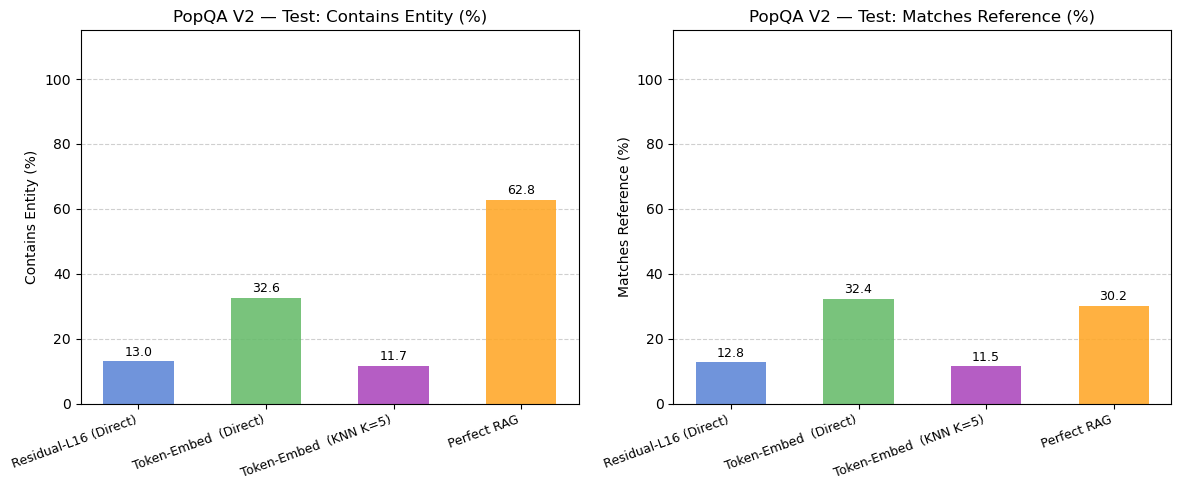

Saved: overall_comparison.png


In [9]:
PLOTS_DIR = os.path.join(cfg.base_dir, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Overall Comparison Bar Chart — Test split ─────────────────────────────────
COLORS = {
    "residual_direct": "#5C85D6",
    "embed_direct":    "#66BB6A",
    "embed_knn":       "#AB47BC",
    "perfect_rag":     "#FFA726",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics  = ["contains_entity", "matches_reference"]
m_labels = ["Contains Entity (%)", "Matches Reference (%)"]

x     = np.arange(len(CONDITIONS))
width = 0.55

for ax, metric, m_label in zip(axes, metrics, m_labels):
    vals   = []
    colors = []
    for cond in CONDITIONS:
        key = (cond, "test")
        if key in eval_dfs:
            val = 100 * pd.to_numeric(eval_dfs[key][metric], errors="coerce").fillna(0).mean()
        else:
            val = 0.0
        vals.append(val)
        colors.append(COLORS[cond])

    bars = ax.bar(x, vals, width, color=colors, alpha=0.88)
    for bar in bars:
        if bar.get_height() > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel(m_label)
    ax.set_title(f"PopQA V2 — Test: {m_label}")
    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "overall_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: overall_comparison.png")

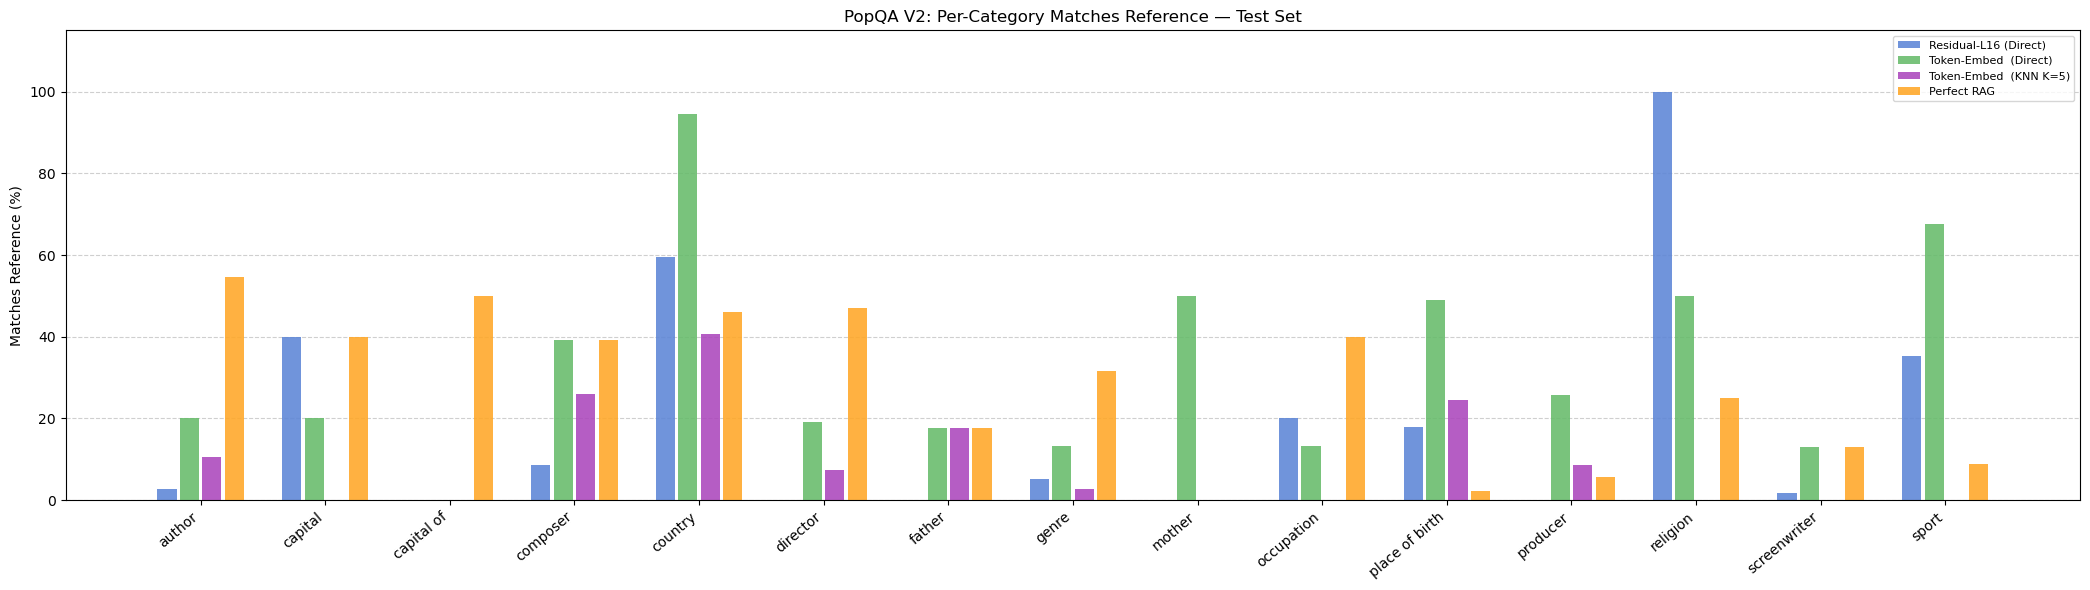

Saved: per_category_comparison.png


In [11]:
# ── Per-Category Breakdown — Test split ───────────────────────────────────────
test_dfs = {cond: eval_dfs.get((cond, "test")) for cond in CONDITIONS}
test_dfs = {k: v for k, v in test_dfs.items() if v is not None}

if test_dfs:
    all_cats = sorted(set(
        cat.lower()
        for df in test_dfs.values()
        for cat in df["category"].dropna().str.lower().unique()
    ))
    x    = np.arange(len(all_cats))
    w    = 0.18
    fig, ax = plt.subplots(figsize=(max(14, len(all_cats) * 1.4), 6))

    for i, cond in enumerate(CONDITIONS):
        df = test_dfs.get(cond)
        if df is None:
            continue
        ce_vals = []
        for cat in all_cats:
            sub = df[df["category"].str.lower() == cat]
            ce  = 100 * pd.to_numeric(sub["matches_reference"], errors="coerce").fillna(0).mean()
            ce_vals.append(ce)
        offset = (i - 1.5) * w
        bars   = ax.bar(x + offset, ce_vals, w * 0.85,
                        label=COND_LABELS[cond], color=COLORS[cond], alpha=0.88)

    ax.set_xticks(x)
    ax.set_xticklabels(all_cats, rotation=40, ha="right")
    ax.set_ylim(0, 115); ax.set_ylabel("Matches Reference (%)")
    ax.set_title("PopQA V2: Per-Category Matches Reference — Test Set")
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6); ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "per_category_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: per_category_comparison.png")


In [ ]:
# ── NN Similarity vs Accuracy (Token-Embed, test) ─────────────────────────────
# Checks whether higher similarity to the nearest training neighbour
# predicts better injection accuracy (validates the KNN assumption).

df_knn_test = eval_dfs.get(("embed_knn", "test"))
if df_knn_test is not None and "word" in df_knn_test.columns:
    # Compute NN similarity for each test entity
    test_keys = [str(w).lower() for w in df_knn_test["word"]]
    keys_tr   = list(embed_vecs_train.keys())
    mat_tr    = torch.stack([embed_vecs_train[k] for k in keys_tr]).float()

    sim_scores = []
    for key_te in test_keys:
        vec = embed_vecs_test.get(key_te)
        if vec is None:
            sim_scores.append(float("nan"))
        else:
            sim_scores.append(
                F.cosine_similarity(vec.float().unsqueeze(0), mat_tr).max().item()
            )

    df_knn_test = df_knn_test.copy()
    df_knn_test["nn_sim"] = sim_scores
    df_knn_test["ce_int"] = pd.to_numeric(df_knn_test["contains_entity"], errors="coerce").fillna(0)

    # Bin by similarity quartile
    df_knn_test["sim_bin"] = pd.qcut(df_knn_test["nn_sim"].dropna(), q=4,
                                      labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
    bin_acc = df_knn_test.groupby("sim_bin", observed=True)["ce_int"].mean() * 100

    fig, ax = plt.subplots(figsize=(7, 4))
    bin_acc.plot(kind="bar", ax=ax, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_xlabel("NN Similarity Quartile (test→train)")
    ax.set_ylabel("Contains Entity Accuracy (%)")
    ax.set_title("Token-Embed KNN: Does NN Similarity Predict Accuracy? (Test)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 105)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                    ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "nn_sim_vs_accuracy.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: nn_sim_vs_accuracy.png")
else:
    print("embed_knn test results not yet available — run Gemini evaluation first.")

print("\nAll plots saved to:", PLOTS_DIR)
